# Long Image Presentation dRSA

Load the `imageRSVP` long-image-presentation array, downsample it from 1000 Hz to 100 Hz with `TimeSeries`, split stimuli into two equal random halves, compute time-resolved RDMs for each half, and run dynamic RSA between the two RDM time series.

In [52]:
from pathlib import Path
import socket
import sys

import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.io import loadmat

PROJECT_ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == "scripts" else Path.cwd().resolve()
CONFIG_PATH = PROJECT_ROOT / "config.yaml"

with CONFIG_PATH.open("r") as f:
    config = yaml.safe_load(f)

host = socket.gethostname()
if host in config:
    machine_key = host
elif "tiziano_mac_mini" in config:
    machine_key = "tiziano_mac_mini"
else:
    machine_key = next(iter(config))

paths = config[machine_key]["paths"]
for path_key in ("src_path", "useful_stuff_path"):
    path = paths.get(path_key)
    if path and path not in sys.path:
        sys.path.append(path)

from useful_stuff.general_utils import TimeSeries
from useful_stuff.general_utils.RSA import dRSA

DATA_PATH = Path(paths["data_path"]) / "data" / "long_img_presentation" / "george_062818_data.mat"
RANDOM_SEED = 0
ORIGINAL_FS = 1000
TARGET_FS = 100
RDM_METRIC = "euclidean"
RSA_METRIC = "correlation"

print(f"Using config: {machine_key}")
print(f"MAT file: {DATA_PATH}")

Using config: tiziano_mac_mini
MAT file: /Users/tizianocausin/sd_local/data/long_img_presentation/george_062818_data.mat


In [66]:
mat = loadmat(DATA_PATH)
image_rsvp = np.asarray(mat["imageRSVP"][32:,:1000,:])
unique_names = mat.get("UniqueNames")

print("imageRSVP shape:", image_rsvp.shape)
print("UniqueNames shape:", None if unique_names is None else unique_names.shape)
print("imageRSVP dtype:", image_rsvp.dtype)

# The MAT file stores imageRSVP as neurons x timepoints x stimuli/trials.
# TimeSeries expects features x time x trials, so no transpose is needed for this file.
n_neurons, n_timepoints, n_stimuli = image_rsvp.shape
assert n_timepoints > n_neurons, "Unexpected imageRSVP axis order; inspect the MAT file before continuing."
assert unique_names is None or unique_names.shape[-1] == n_stimuli or unique_names.size == n_stimuli

image_ts = TimeSeries(image_rsvp, fs=ORIGINAL_FS)
print("Original TimeSeries shape:", image_ts.shape(), "fs:", image_ts.get_fs())

imageRSVP shape: (31, 1000, 651)
UniqueNames shape: (1, 651)
imageRSVP dtype: float64
Original TimeSeries shape: (31, 1000, 651) fs: 1000


In [67]:
image_ts.resample(TARGET_FS)
print("Resampled TimeSeries shape:", image_ts.shape(), "fs:", image_ts.get_fs())
print("Duration (ms):", image_ts.get_duration_ms())

Resampled TimeSeries shape: (31, 100, 651) fs: 100
Duration (ms): 1000.0


In [68]:
rng = np.random.default_rng(RANDOM_SEED)
indices = rng.permutation(n_stimuli)
n_per_split = n_stimuli // 2
split_a_idx = np.sort(indices[:n_per_split])
split_b_idx = np.sort(indices[n_per_split:2 * n_per_split])
left_out_idx = np.sort(indices[2 * n_per_split:])

split_a = TimeSeries(image_ts.get_array()[:, :, split_a_idx], fs=image_ts.get_fs())
split_b = TimeSeries(image_ts.get_array()[:, :, split_b_idx], fs=image_ts.get_fs())

print(f"Stimuli/trials total: {n_stimuli}")
print(f"Split A: {split_a.shape()}")
print(f"Split B: {split_b.shape()}")
print(f"Left out stimulus indices: {left_out_idx.tolist()}")

Stimuli/trials total: 651
Split A: (31, 100, 325)
Split B: (31, 100, 325)
Left out stimulus indices: [607]


In [69]:
rsa = dRSA(
    signal_RDM_metric=RDM_METRIC,
    model_RDM_metric=RDM_METRIC,
    RSA_metric=RSA_METRIC,
)

rsa.compute_both_RDM_timeseries(signal=split_a, model=split_b)
print("Signal RDM time series type:", type(rsa.signal_RDM_timeseries).__name__)
print("Model RDM time series type:", type(rsa.model_RDM_timeseries).__name__)
print("Number of time points:", len(rsa.signal_RDM_timeseries))
print("RDM vector length:", len(rsa.signal_RDM_timeseries[0]))

Signal RDM time series type: TimeSeries
Model RDM time series type: TimeSeries
Number of time points: 100
RDM vector length: 52650


In [70]:
dRSA_mat = rsa.compute_dRSA()
print("dRSA matrix shape:", dRSA_mat.shape)

dRSA matrix shape: (100, 100)


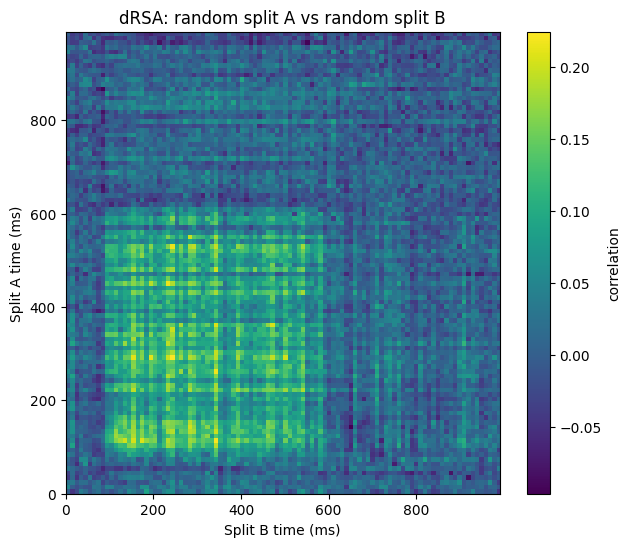

In [71]:
time_ms = np.arange(dRSA_mat.shape[0]) * 1000 / TARGET_FS

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(
    dRSA_mat,
    origin="lower",
    aspect="auto",
    extent=[time_ms[0], time_ms[-1], time_ms[0], time_ms[-1]],
    cmap="viridis",
)
ax.set_xlabel("Split B time (ms)")
ax.set_ylabel("Split A time (ms)")
ax.set_title("dRSA: random split A vs random split B")
fig.colorbar(im, ax=ax, label=RSA_METRIC)
plt.show()

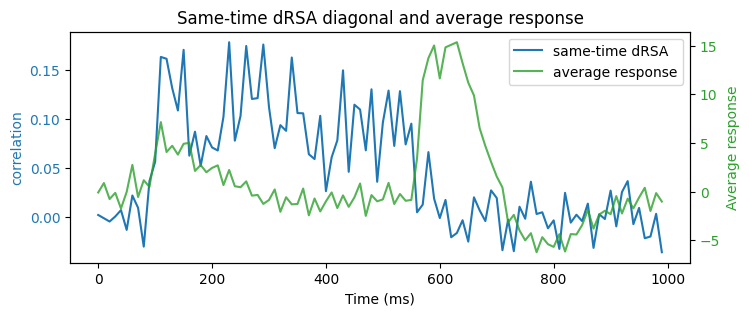

In [72]:
# Optional: inspect the same-time dRSA diagonal alongside the average response.
diagonal_dRSA = np.diag(dRSA_mat)
average_response = image_ts.overall_avg()

fig, ax = plt.subplots(figsize=(8, 3))
line_drsa, = ax.plot(time_ms, diagonal_dRSA, color="tab:blue", label="same-time dRSA")
ax.set_xlabel("Time (ms)")
ax.set_ylabel(RSA_METRIC, color=line_drsa.get_color())
ax.tick_params(axis="y", labelcolor=line_drsa.get_color())

ax_response = ax.twinx()
line_response, = ax_response.plot(
    time_ms,
    average_response,
    color="tab:green",
    alpha=0.8,
    label="average response",
)
ax_response.set_ylabel("Average response", color=line_response.get_color())
ax_response.tick_params(axis="y", labelcolor=line_response.get_color())

ax.set_title("Same-time dRSA diagonal and average response")
ax.legend([line_drsa, line_response], [line_drsa.get_label(), line_response.get_label()], loc="best")
plt.show()

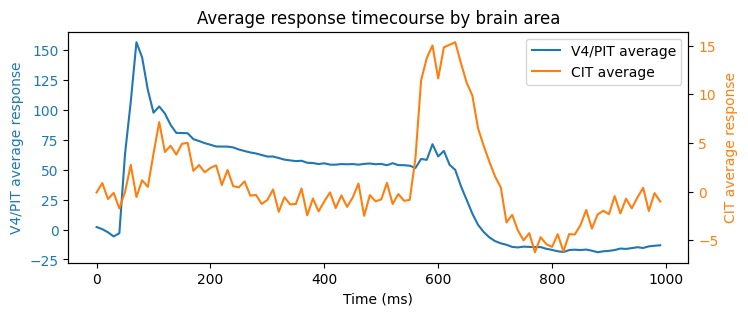

In [77]:
v4_pit_ts = TimeSeries(np.asarray(mat["imageRSVP"][:32, :1000, :]), fs=ORIGINAL_FS)
cit_ts = TimeSeries(np.asarray(mat["imageRSVP"][32:, :1000, :]), fs=ORIGINAL_FS)

v4_pit_ts.resample(TARGET_FS)
cit_ts.resample(TARGET_FS)

v4_pit_average = v4_pit_ts.overall_avg()
cit_average = cit_ts.overall_avg()
area_time_ms = np.arange(len(v4_pit_average)) * 1000 / TARGET_FS

fig, ax_v4_pit = plt.subplots(figsize=(8, 3))
line_v4_pit, = ax_v4_pit.plot(
    area_time_ms,
    v4_pit_average,
    color="tab:blue",
    label="V4/PIT average",
)
ax_v4_pit.set_xlabel("Time (ms)")
ax_v4_pit.set_ylabel("V4/PIT average response", color=line_v4_pit.get_color())
ax_v4_pit.tick_params(axis="y", labelcolor=line_v4_pit.get_color())

ax_cit = ax_v4_pit.twinx()
line_cit, = ax_cit.plot(
    area_time_ms,
    cit_average,
    color="tab:orange",
    label="CIT average",
)
ax_cit.set_ylabel("CIT average response", color=line_cit.get_color())
ax_cit.tick_params(axis="y", labelcolor=line_cit.get_color())

ax_v4_pit.set_title("Average response timecourse by brain area")
ax_v4_pit.legend(
    [line_v4_pit, line_cit],
    [line_v4_pit.get_label(), line_cit.get_label()],
    loc="best",
)
plt.show()